In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
N_CLASSES=21

def _dilinear_kernel(in_ch, out_ch, k):
    factor = (k+1) // 2
    center = factor -1 if k%2 == 1 else factor - 0.5
    og_y = torch.arange(k).reshape(-1,1)
    og_x = torch.arange(k).reshape(1,-1)
    filt = (1 - torch.abs(og_y-center)/factor * (1-torch.abs(og_x-center/factor)))
    weight = torch.zeros((in_ch, out_ch, k, k))
    for i in range(in_ch):
        for j in range(out_ch):
            weight[i,j] = filt
    return weight

class FCN8s(nn.Module):
    def __init__(self, n_class, use_interpolate=True):
        super().__init__()
        self.n_class = n_class
        self.use_interpolate = use_interpolate

        # 인코더
        self.block1 = nn.Sequential(
            nn.Conv2d(3,64,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /2
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64,128,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /4
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128,256,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /8
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(256,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /16
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(512,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /32
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(512,4096,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )
        self.conv7 = nn.Sequential(
            nn.Conv2d(4096,4096,3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )
        self.score_fr = nn.Conv2d(4096, n_class, kernel_size=1) # 모든 화소 탐색
        self.score_pool4 = nn.Conv2d(512, n_class, kernel_size=1) 
        self.score_pool3 = nn.Conv2d(256, n_class, kernel_size=1) 

        # 디코더
        self.upscore2 = nn.ConvTranspose2d(n_class, n_class, kernel_size=4, stride=2, padding=1, bias=False)
        self.upscore_pool4 = nn.ConvTranspose2d(n_class, n_class, kernel_size=4, stride=2, padding=1, bias=False)
        self.upscore8 = nn.ConvTranspose2d(n_class, n_class, kernel_size=16, stride=8, padding=4, bias=False)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d): # 오른쪽에 입력한 클래스인지 확인하는 코드 = type과 거의 동일
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        self.upscore2.weight.data.copy_(_dilinear_kernel(self.n_class, self.n_class, 4))
        self.upscore_pool4.weight.data.copy_(_dilinear_kernel(self.n_class, self.n_class, 4))
        self.upscore8.weight.data.copy_(_dilinear_kernel(self.n_class, self.n_class, 16))


    def forward(self, x):
        H,W = x.shape[-2:]

        # 인코더층
        h = self.block1(x)
        h = self.block2(h)
        pool3 = self.block3(h)
        pool4 = self.block4(pool3)
        pool5 = self.block5(pool4)
        
        # 분류층
        h = self.conv6(pool5)
        h = self.conv7(h)
        score_fr = self.score_fr(h) # /32

        # 디코더층1
        upscore2 = self.upscore2(score_fr) # /16
        score_pool4 = self.score_pool4(pool4) # /16
        fuse_pool4 = upscore2 + score_pool4
        
        # 디코더층2
        upscore_pool4 = self.upscore_pool4(fuse_pool4) # 
        score_pool3 = self.score_pool3(pool3)
        fuse_pool3 = upscore_pool4 + score_pool3
        
        # 디코더층3 /1 => 원본 사이즈로 조정
        out = self.upscore8(fuse_pool3) # (B,C,H,W)

        # 해상도 오차 조정(입력 크기 차이성) 이미지 크기가 짝수면 문제가 안되지만 홀수일 경우가 문제여서 이 코드가 필요함
        if self.use_interpolate and ((out.shape[-2:]) != (H, W)):
            out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return {'out':out}

In [2]:
# 학습 속도는 m이 제일 빠름(초기 가중치가 랜덤으로 되어 있고 파라미터가 작기 때문)
m = FCN8s(n_class=N_CLASSES)

In [3]:
from torchvision import models
m1 = models.segmentation.fcn_resnet50(
    weights=None, # 랜덤 초기화
    weights_backbone=None, # 백본 가중치
    num_classes = N_CLASSES
)

In [4]:
weights = models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
m2 = models.segmentation.fcn_resnet50(weights=weights, num_classes=N_CLASSES)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as TF
import os

In [ ]:
IMG_SIZE = 512
IGNORE_INDEX = 255 # 화소
VOC_CLASSES = [
"background",
"aeroplane","bicycle","bird","boat",
"bottle","bus","car","cat","chair",
"cow","diningtable","dog","horse","motorbike",
"person","pottedplant","sheep","sofa","train","tvmonitor"
]
device = torch.device('cpu')
PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

def denorm(img):
    mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
    std = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
    # mean = torch.tensor([0.485, 0.456, 0.406], device=device)[:,None,None]
    # std = torch.tensor([0.229, 0.224, 0.225], device=device)[:,None,None]
    return (img*std + mean).clamp(min=0, max=1)

def colorize_mask(mask_np):
    m = mask_np.copy()
    m[m == IGNORE_INDEX] == 0 # 무시화소가 있는가 => 분할데이터에 있는 엣지구간을 제거하기 위함
    return PAL[m]

def preprocess_image_for_infer(img_path):
    img = Image.open(img_path).convert('RGB')
    img_r = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    t = TF.to_tensor(img_r)
    t = TF.normalize(t, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    return img, t.unsqueeze(0)

# 아래 함수는 부위 파악용이므로 무조건 필요한 코드는 아님
def annotate_classes_on_segments(ax, pred_mask_resize, classes, ignore_index=255, bg_color='white'):
    uniq = np.unique(pred_mask_resize)
    uniq = uniq[uniq != ignore_index]
    for cls_id in uniq:
        if not (0 <= cls_id < len(classes)):
        # if not (0 <= cls_id == len(classes)):
            continue
        ys, xs = np.where(pred_mask_resize==cls_id)
        if ys.size == 0:
            continue
        cy, cx = float(ys.mean()), float(xs.mean())
        ax.text(cx,cy, classes[cls_id], ha='center', va='center', fontsize=11, color='black', 
                bbox=dict(facecolor=bg_color, alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 어차피 gpu로 할 거임
@torch.no_grad()        
def infer_one_image_pretrained(img_path, save_path=None, overlay=True, alpha=0.6):
    weights = models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
    m = models.segmentation.fcn_resnet50(weights=weights, num_classes=N_CLASSES).to(device)
    m.eval()

    pil_oj, t = preprocess_image_for_infer(img_path)
    t = t.to(device)
    out = m(t)['out'] # 1, 21, 512, 512
    pred_512 = out.argmax(1)[0].cpu().numpy() # 512,512
    vis_mask = colorize_mask(pred_512) # 512,512,3
    if overlay:
        den = (denorm(t[0]).cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        vis_512 = (den * (1 - alpha) + vis_mask * alpha).astype(np.uint8)
        # vis_512 = (den * (1 - alpha) * vis_mask * alpha).astype(np.uint8)
    else:
        vis_512 = vis_mask
    out_vis_pil = Image.fromarray(vis_512).resize(pil_oj.size, resample=Image.NEAREST)
    pred_orig = np.array(Image.fromarray(pred_512.astype(np.uint8)).resize(pil_oj.size, resample=Image.NEAREST))

    plt.figure(figsize=(10,5))
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(pil_oj)
    ax1.axis('off')
    ax2 = plt.subplot(1,2,2)
    ax2.imshow(out_vis_pil)
    ax2.axis('off')
    annotate_classes_on_segments(ax2, pred_orig, VOC_CLASSES, IGNORE_INDEX)
    plt.show()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        save_path.save(save_path)
        print(f'저장완료: {save_path}')
    uniq = np.unique(pred_orig)
    uniq = uniq[uniq != IGNORE_INDEX]
    detected = [VOC_CLASSES[i] for i in uniq if 0 <= i < len(VOC_CLASSES)]
    print(f'분할된 클래스: {detected}')

    return pred_orig, out_vis_pil

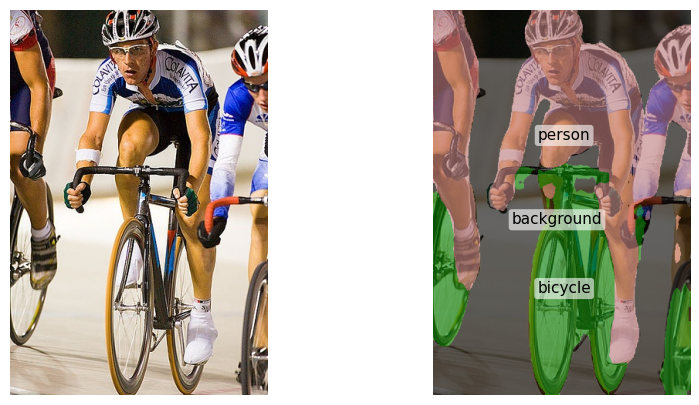

분할된 클래스: ['background', 'bicycle', 'person']


In [7]:
pred, vis = infer_one_image_pretrained('data/VOCdevkit/VOC2012/JPEGImages/2007_000129.jpg')

In [8]:
# 분할은 EPOCH 수를 최소 100회는 시도해야된다고 하심
import os, time
from pathlib import Path
import numpy as np
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F
# 사실은 로스값으로만 판단하기엔 조금 어려우므로 시각화를 동작마다 확인할 것임
import matplotlib.pyplot as plt

In [9]:
# 상수 정의
DATA_ROOT = './data/VOCdevkit'
SPLIT = 'VOC2012'
BATCH_SIZE = 32
EPOCHS = 5
LR = 5e-3 # 초반엔 작게 주는 게 좋음
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

IMG_SIZE = 512
N_CLASSES = 21
IGNORE_INDEX = 255

OUT_DIR = 'runs/fcn_scratch'
BEST_PATH = os.path.join(OUT_DIR, 'best_m.pth')
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# 데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img, mask):
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1) < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask
    return _tfm

class VOCDatasetTrain(Dataset):
    def __init__(self, root, split, image_set, transforms=None):
        base = Path(root)/split
        self.img_dir = base/'JPEGImages'
        self.mask_dir = base/'SegmentationClass'
        with open(base/'ImageSets'/'Segmentation'/f'{image_set}.txt') as f:
            self.ids = [x for x in f if x.strip()]
        self.tfm = transforms
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        id_ = self.ids[index]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask

class VOCDatasetVal(VOCDatasetTrain):
    def __getitem__(self, idx):
        id_ = self.ids[idx]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask, id_

def get_loader():
    tr_ds = VOCDatasetTrain(DATA_ROOT, SPLIT, 'train', transforms=make_transform(train=True))
    val_ds = VOCDatasetVal(DATA_ROOT, SPLIT, 'val', transforms=make_transform(train=False))
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)    
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    # tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=4)    
    # val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=4)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader    

In [11]:
# 색 정립 (배경 /무시 정립)
PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)
BG_COLOR = np.array([50,50,50], dtype=np.uint8) # 배경: 
IGNORE_COLOR = np.array([100,100,100], dtype=np.uint8) # 무시: 밝은 회색

def _denorm(img):
    mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
    std = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
    return (img*std + mean).clamp(0, 1)

def _colorize_mask(mask_np):
    out = PAL[np.clip(mask_np, 0, len(PAL))].copy()
    out[mask_np == 0] = BG_COLOR
    out[mask_np == IGNORE_INDEX] = IGNORE_COLOR
    return out

@torch.no_grad()
def visualize_val_grid_random(epoch, model, val_ds, device, out_dir=OUT_DIR, samples=4):
    if len(val_ds) == 0:
        print('검증 안함')
        return
    os.makedirs(out_dir, exist_ok=True)
    idxs = np.random.choice(len(val_ds), size=min(samples, len(val_ds)), replace=False)
    imgs, gts = [], []
    for idx in idxs:
        img, mask, _ = val_ds[idx]
        imgs.append(img)
        gts.append(mask)
    batch = torch.stack(imgs).to(device)
    gts_np = [m.numpy for m in gts]
    
    model.eval()
    out = model(batch)
    out = out['out'] if isinstance(out, dict) else out
    preds = out.argmax(1).detach().cpu().numpy()

    B = len(idxs)
    f, ax = plt.subplot(B, 3, figsize = (12,3*B))

    if B == 1:
        ax = np.expand_dims(ax, 0)
    for i in range(B):
        img_np = _denorm(batch).detach().cpu().numpy()
        gt_rgb = _colorize_mask(gts_np, IGNORE_INDEX)
        pred_rgb = _colorize_mask(preds[i], IGNORE_INDEX)

        ax[i:0].imshow(img_np)
        ax[i:0].set_title('oj_img')
        ax[i:0].axis('off')
        ax[i:1].imshow(gt_rgb)
        ax[i:1].set_title('oj_mask')
        ax[i:1].axis('off')
        ax[i:2].imshow(pred_rgb)
        ax[i:2].set_title('pr_mask')
        ax[i:2].axis('off')
    plt.suptitle(f'val_(R)-Epoch{epoch}')
    save_path = os.path.join(out_dir, f'val_(R)-Epoch{epoch}.grid.png')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close() # save를 하면 가급적 close로 종료해줄 것
    print(f'기록됨: {save_path}')

In [ ]:
from tqdm import tqdm
# 모델 학습
m = FCN8s(n_class=N_CLASSES)
# m = models.segmentation.fcn_resnet50(weights=None, weights_backbone=None, num_classes=N_CLASSES)
# m = models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1, num_classes=N_CLASSES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
m.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt = torch.optim.SGD(m.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loader()

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    num = 0.0
    den = 0.0
    for x,y in loader:
        img, mask = x.to(device), y.to(device)
        out = model(img)
        out = out['out'] if isinstance(out, dict) else out

        loss_map = F.cross_entropy(out, mask, ignore_index=IGNORE_INDEX, reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        num += (loss_map * valid).sum().item()
        den += valid.sum().item()
    return num/max(1.0, den)

best_loss = float('inf')
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    m.train()
    r_num = 0.0
    r_den = 0.0
    for x, y in tqdm(tr_ds_loader):
        img, mask = x.to(device), y.to(device)
        out = m(img)
        out = out['out'] if isinstance(out, dict) else out
        loss_map = F.cross_entropy(out, mask, ignore_index=IGNORE_INDEX, reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        loss = (loss_map * valid).sum()/valid.sum().clamp_min(1.0)
        
        opt.zero_grad() # 여기선 set_to_none=True 로 설정하는 것도 좋음
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # 발산을 안정화하기 위한 장치
        opt.step()

        r_num += (loss_map * valid).sum().item()
        r_den += valid.sum().item()
    tr_loss = r_num/max(1.0, r_den)
    val_loss = evaluate(m, val_ds_loader, device)
    dt = time.time() - t0
    print(f'Epoch{epoch}/{EPOCHS} tr_loss:{tr_loss}, val_loss:{val_loss}, time:{dt}')

    if epoch % 1 == 0: # 그냥 매번 돌릴 거임
        visualize_val_grid_random(epoch, m, val_ds_loader, device)
    if best_loss-1e-8 > val_loss :
        best_loss = val_loss
        ckpt = {
            'epoch': epoch,
            'm_state': m.state_dict(),
            'opt': opt.state_dict(),
            'val_loss': val_loss
        }
        torch.save(ckpt, BEST_PATH)
        print(f'[BEST] val_loss:{val_loss} -> {BEST_PATH} 저장')

  0%|          | 0/46 [00:14<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 672.00 MiB. GPU 0 has a total capacity of 16.00 GiB of which 0 bytes is free. Of the allocated memory 13.31 GiB is allocated by PyTorch, and 499.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)